In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_50771/3312677084.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


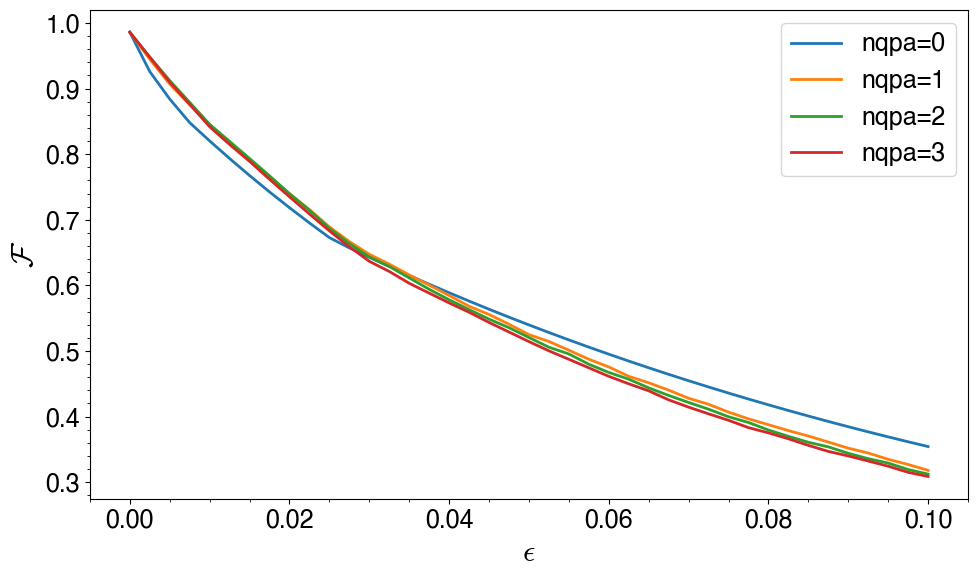

In [21]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
plt.legend()
plt.savefig('aer_trotter_estimation/big.pdf', bbox_inches='tight')

plt.show()
plt.close()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_50771/1365741703.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


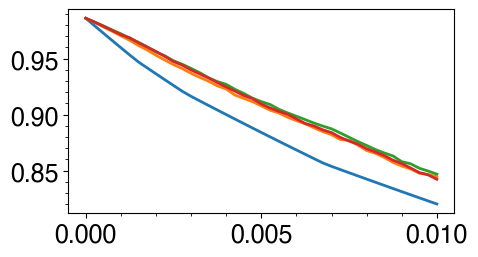

In [23]:
plt.figure(figsize=(5, 2.8))
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
# plt.xlabel('$\epsilon$')
# plt.ylabel('$\mathcal{F}$')
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([0.85, 0.90, 0.95])
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/inset.pdf', bbox_inches='tight')
plt.show()

## Rydberg estimation plotting

Average base fidelity: 0.8201289239384646
0.8201289239384646


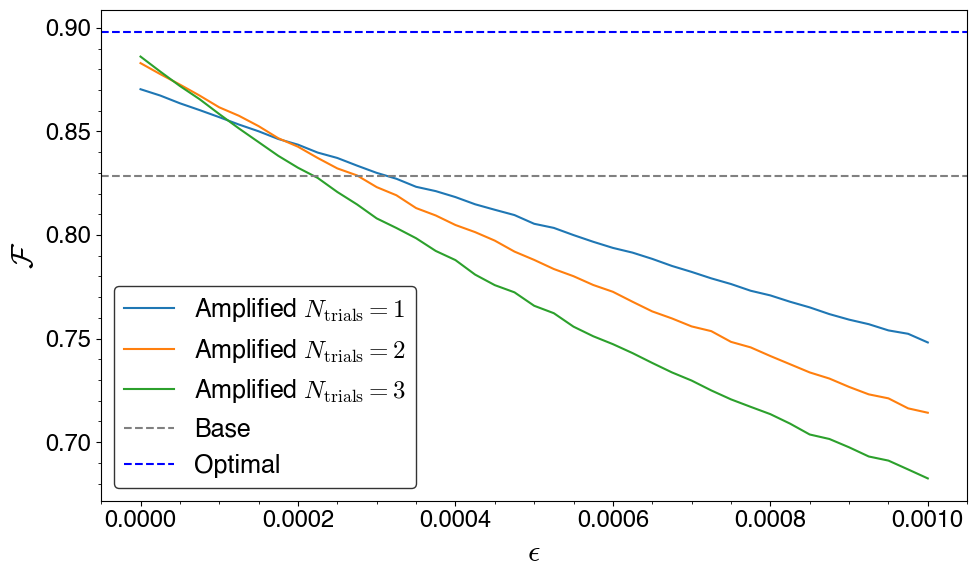

Plot saved to: aer_ryd_estimation/plotting_results/fidelity_125_k4_nshots102400_eps0.0-0.001_s41.pdf


In [1]:
import os
import csv
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 17          # Tick labels
mpl.rcParams['ytick.labelsize'] = 17
# ==========================================================================

# === CONFIGURATION ========================================================
nshots      = 102400
k           = 4
eps_steps   = 41
eps_min     = 0.0
eps_max     = 0.001
eigenstates = 5

base_folder = (
    f"aer_ryd_estimation/simulation_outputs/"
    f"ryd_estimation_{eigenstates**3}_eigenstates_k{k}_shots{nshots}"
    f"_eps{eps_min}-{eps_max}_s{eps_steps}"
)
outfile_pdf = (
    f"aer_ryd_estimation/plotting_results/"
    f"fidelity_{eigenstates**3}_k{k}_nshots{nshots}_eps{eps_min}-{eps_max}_s{eps_steps}.pdf"
)

datafile           = "aer_ryd_estimation/all_states_5_eigenstates.npz"
exact_state_file   = "aer_ryd_estimation/exact_state.npz"
# ==========================================================================

# === LOAD PROBABILITIES AND STATES =======================================
data         = np.load(datafile, allow_pickle=True)
probs        = data["probs"]
input_states = data["states"]

exact_state  = np.load(exact_state_file, allow_pickle=True)["state"]
# ==========================================================================

# === COMPUTE BASE FIDELITY ===============================================
avg_base_fidelity = 0.0
for prob, state_tuple in zip(probs, input_states):
    q3_input_state = state_tuple[1]                       # third register state
    fid            = abs(np.vdot(q3_input_state, exact_state))**2
    avg_base_fidelity += prob * fid
print("Average base fidelity:", avg_base_fidelity)
print(avg_base_fidelity)
# ==========================================================================

# === LOAD QPA RESULTS, WEIGHT BY PROBS ====================================
fidelity_qpa = defaultdict(list)

for idx, prob in enumerate(probs):
    input_path = os.path.join(base_folder, f"index{idx}")
    if not os.path.exists(input_path):
        print("Missing:", input_path)
        continue

    for folder in os.listdir(input_path):
        if not folder.startswith("nqpa"):
            continue
        nqpa_val  = int(folder.replace("nqpa", ""))
        csv_path  = os.path.join(input_path, folder, "merged_results.csv")
        if not os.path.exists(csv_path):
            print("Missing CSV:", csv_path)
            continue

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            header = next(reader)               # "epsilon, fidelity"
            for eps_str, fid_str in reader:
                eps = float(eps_str)
                fid = float(fid_str)
                fidelity_qpa[nqpa_val].append((eps, fid * prob))
# ==========================================================================

# === GROUP & AGGREGATE ====================================================
final_qpa = {}
for nqpa, entries in fidelity_qpa.items():
    buckets = defaultdict(list)
    for eps, w_fid in entries:
        buckets[eps].append(w_fid)
    final_qpa[nqpa] = {eps: sum(vals) for eps, vals in buckets.items()}
# ==========================================================================

# === PLOTTING =============================================================
plt.figure(figsize=(10, 6))

for nqpa in sorted(final_qpa.keys()):
    eps_list     = sorted(final_qpa[nqpa].keys())
    fidelities   = [final_qpa[nqpa][eps] for eps in eps_list]
    label_prefix = "Unamplified" if nqpa == 0 else f"Amplified $N_{{\\mathrm{{trials}}}}={nqpa}$"
    plt.plot(eps_list, fidelities, label=label_prefix)

plt.axhline(y=0.8284986603752338, linestyle="--", color="gray", label="Base")
plt.axhline(y=0.897822559792652, linestyle="--", color="blue", label="Optimal")

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tick_params(which="both", direction="out")

plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\mathcal{F}$")
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()

plt.savefig(outfile_pdf)
plt.show()

print("Plot saved to:", outfile_pdf)
